# Docker, one experiment at a time — v2
### From Python virtual environments to a two-service Compose application

**Build an image. Run containers. Publish an image. Keep data. Connect services.**

Our recurring example is **Porter**, a tiny Python HTTP app. It shows a message,
records visits, and tells us which container answered. It first stores its count
in a file; at the end, the same image uses a separate Redis container.

**Audience:** learners who know Python and virtual environments, with no Docker experience.

**Format:** explanation → prediction → command → observation → small change.
Open the answer boxes after discussing each prediction. Outputs start empty so
the results shown in class come from the learner's own machine.

> Work through this notebook section by section. **Do not use Run All.** Some
> activities need a terminal, registry credentials, or an intentional data reset.
> The registry section is optional; all later sections work without an account.

**New in v2:** comments above executable code lines and command arguments; Python
image variants with Docker Hub links and a live size comparison; five embedded
visual diagrams. The teaching examples and section order from v1 are retained.

## Route through the workshop

| Section | What learners will do | Suggested live time |
|---|---|---:|
| 0–1 | Check the setup; connect Docker to what a venv does | 10 min |
| 2–3 | Run a ready-made image; write and build our own | 20 min |
| 4–5 | Separate foreground, interactive, and detached runs; manage containers | 20 min |
| 6 | Tag, log in, push, pull | 10 min |
| 7–9 | Observe data loss, named-volume persistence, and bind mounts | 25 min |
| 10–11 | Connect Porter to Redis using Compose | 25 min |
| 12 | Solve the practice tasks | 10 min |
| Appendix | Extra experiments, troubleshooting, cleanup, command reference | As needed |

This is a **roughly two-hour instructor-led route** with setup completed in advance.
Allow 2.5–3 hours for a group following every experiment. Skip the optional appendix
and use one instructor push demonstration if time is tight.

By the end, explain why `docker build`, `docker run`, and `docker compose up`
are different operations, and choose the right storage for a given application.

## 0 · Setup and how to use the commands

Install Docker Desktop on Windows/macOS, or Docker Engine and the Compose plugin
on Linux. Start Docker before opening the notebook. On Windows, select **Linux
containers**. Use a current Docker installation and Compose v2 (`docker compose`,
with a space). These examples use current relative bind-mount syntax and Compose
`--wait`; update if your installation does not recognize them.

Run Jupyter with a **Python 3 kernel on your own computer**, where the Docker CLI
can reach the local Docker daemon. A regular hosted Colab notebook is not this
environment. Have internet access for the initial image pulls and Python packages,
and keep local ports **8000** and **8080** free. A Docker Hub account is needed only
for publishing. The image installs Flask and redis-py; the notebook does not need them.

| In this notebook | In your terminal |
|---|---|
| `!docker image ls` | `docker image ls` |
| `!curl ...` | `curl ...` (PowerShell: use `curl.exe` if `curl` is an alias) |
| `%%writefile app.py` followed by text | Create `app.py` in an editor and paste only the text below the magic |
| `%cd ...` | `cd ...` |
| A Python `Path(...)` setup/read cell | Use the equivalent folder action or open the file in your editor |

**All Docker operations use plain `!docker ...` cells.** There are no subprocess
calls, Docker SDK calls, or hidden command runners. Remove the initial `!` to copy
a command to a terminal. Keep your terminal in the project folder printed below.

Cells labeled **TERMINAL ONLY** are shown as copyable command blocks. Jupyter's
`!` execution generally has no interactive TTY, so `-it`, login prompts, foreground
servers, and continuous log streams belong in a terminal.

Install instructions: [Docker Desktop](https://docs.docker.com/get-started/get-docker/)
and [Docker Engine on Linux](https://docs.docker.com/engine/install/).

**Reading the comments:** each command has explanations immediately above it.
Copy the command line without `!` into your terminal; the `#` comments are also
valid in Bash/PowerShell. `%%writefile` must remain the first line of its cell: its
explanation is placed directly above the cell, and comments inside the generated
file explain each instruction. The banner-writing cells use Python because plain
text banner files do not have a comment syntax.

In [ ]:
# Print Docker Client and Server versions; a missing Server section usually means the daemon
# cannot be reached.
!docker version

In [ ]:
# Print the Compose plugin version; this verifies the docker compose command is installed.
!docker compose version

In [ ]:
# Show the selected Docker context, which determines which Docker daemon receives these
# commands.
!docker context show

**Observe:** `docker version` should show both **Client** and **Server**. A client
version alone does not prove that the daemon is running. The context should point
to the local Engine or Docker Desktop you intend to use, not an unrelated remote server.
If these fail, use the troubleshooting table before continuing.

The next two cells create and enter `docker_porter_lab`. They do not launch Docker.
Rerunning `%%writefile` cells overwrites the corresponding **lab files**.

In [ ]:
# Import Path for portable file and directory operations.
from pathlib import Path

# Read the Python kernel's current working directory.
workshop_dir = Path.cwd()
# Avoid nesting another lab folder when this setup cell is rerun from inside it.
if workshop_dir.name != "docker_porter_lab":
    # Append the lab folder name using Path's OS-aware path joining.
    workshop_dir = workshop_dir / "docker_porter_lab"
# Create the lab folder; exist_ok=True makes an already-existing folder acceptable.
workshop_dir.mkdir(exist_ok=True)
# Print the absolute project path so your terminal can cd to the same folder.
print("Project folder:", workshop_dir.resolve())

In [ ]:
# Change the notebook working directory; IPython expands {workshop_dir}, and quotes preserve
# spaces. In a terminal, cd to the printed path.
%cd "{workshop_dir}"

**Terminal setup alternative:** create a folder named `docker_porter_lab` and `cd`
into it. For every `%%writefile` cell below, create that named file in this folder.
You can now follow the entire workshop from a terminal and text editor.

## 1 · Why Docker if we already have virtual environments?

A venv answers: **“Which Python packages should this Python project import?”**
Docker lets us package an application with its runtime and user-space dependencies,
then run it with an isolated filesystem, process view, and network environment.

Imagine sharing a Python service that also needs a particular Python version,
Linux libraries, startup command, and a Redis server. A requirements file describes
only part of that setup. An image describes the app's packaged environment;
Compose will describe how its services run together.

| Question | Python venv | Docker container | Virtual machine |
|---|---|---|---|
| Python packages isolated? | Yes, typically | Yes, through its filesystem | Yes, inside its guest OS |
| Python interpreter | Uses the base interpreter used to create it | Can ship an interpreter in the image | Installed inside the guest |
| User-space OS libraries | Uses the host's | Can ship them in the image | Guest OS provides them |
| Processes and networking | Uses the host environment directly | Usually isolated by the runtime | Isolated in the guest |
| Kernel | Host kernel | Shares the container host's kernel | Has a guest kernel |

Linux containers on Docker Desktop for macOS/Windows use a **Linux VM**. The
container does not contain its own Linux kernel. OS and CPU architecture still
matter: an image built only for one architecture is not automatically native on another.

| Term | Meaning in this lab |
|---|---|
| Dockerfile | Recipe for constructing the app image |
| Image | Packaged filesystem layers plus configuration; the reusable template |
| Container | An instance created from an image, with runtime settings and a writable layer |
| Docker Engine / daemon | Runs and manages containers on the Docker host |
| Registry | Stores images for distribution; Docker Hub is one example |
| Repository and tag | A named image collection and a label, e.g. `yourname/porter:1.0` |

A stopped container is still a container. Creating two containers from an image
does not make edits in one appear in the other, unless you deliberately share storage.

### Visual model: building, running, and publishing are different actions

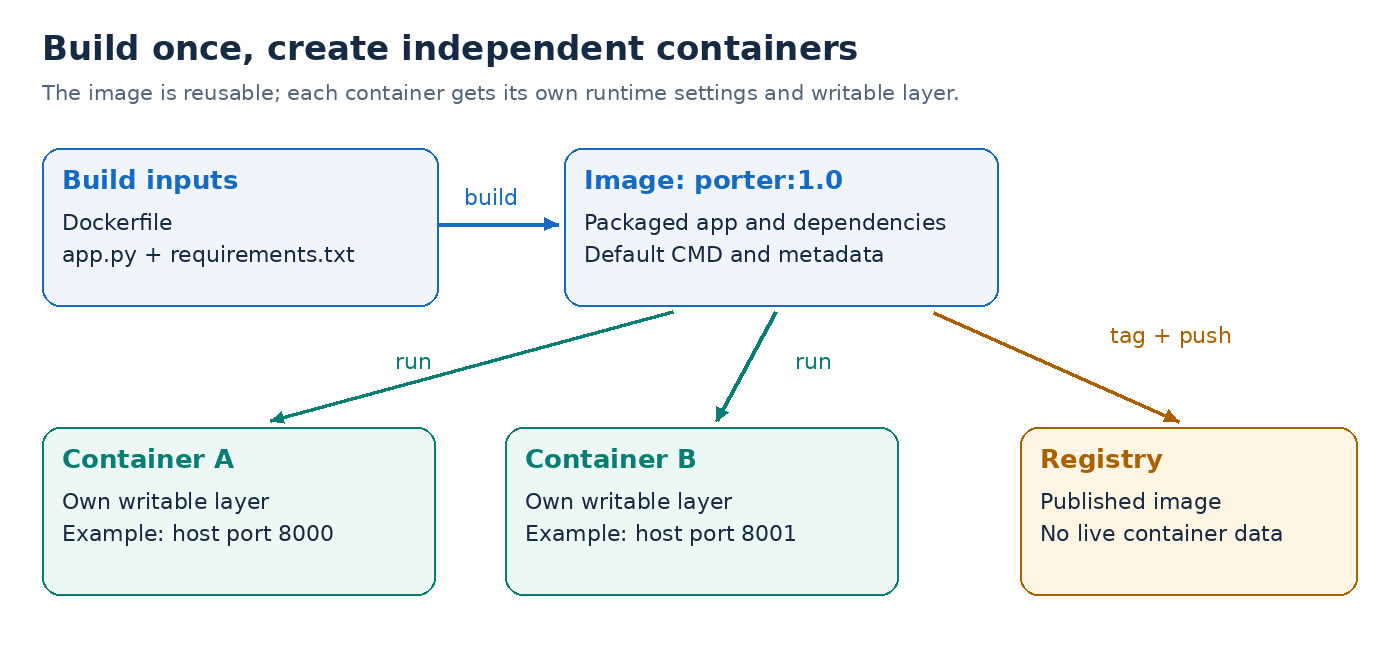

**Predict before running:** If you activate a different venv on your laptop, does it change Python inside an already-built image?

<details>
<summary>Reveal the explanation</summary>

No. The image supplies its own Python environment. The host venv may run Jupyter, but it does not select the interpreter inside the container.

</details>

## 2 · Run an image before building one

### 2.1 A first short-lived container

`run` creates and starts a **new** container. If the image is missing locally,
Docker normally pulls it. `--rm` removes this container after its process exits.

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# hello-world: the image repository; omitting the tag selects the tag latest.
# hello-world uses its own default command: print a welcome message and exit. Docker pulls a
# missing image automatically.
!docker run --rm hello-world

**Observe:** the welcome text is the container's output. It exited normally; it is
not a server that should stay running. `--rm` removes the container, not its image.

In [ ]:
# List locally stored images, including tags, image IDs, and size information.
!docker image ls

In [ ]:
# List running containers.
!docker ps

### 2.2 Use Python without installing that version on the host

The words after the image name select the command to run inside the new container.
These commands finish, so they are safe to run directly in Jupyter.

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# python:3.12-slim: the image reference used to create this container; the text after : is its
# tag.
# python --version: override the image's CMD, print its Python version, then exit.
!docker run --rm python:3.12-slim python --version

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# python:3.12-slim: the image reference used to create this container; the text after : is its
# tag.
# cat /etc/os-release: override CMD and print that file inside the container, then exit.
!docker run --rm python:3.12-slim cat /etc/os-release

**Predict before running:** After these commands, should `docker ps` show a Python container still running?

<details>
<summary>Reveal the explanation</summary>

No. Each selected command finished, and --rm removed its container. A container stays running only while its main process is alive. The image remains cached locally.

</details>

## 3 · Write an app and build its image

### 3.1 Our tiny application

| Request | What it does |
|---|---|
| `GET /` | Shows the message, count, storage backend, container hostname, and code version |
| `POST /visit` | Adds one visit |
| `GET /health` | Checks the app; in Redis mode, also checks the Redis connection |

Without `REDIS_URL`, the count is stored at `/data/counter.txt`. With `REDIS_URL`,
the count is stored in Redis. An optional `/config/banner.txt` overrides the message;
we will mount it later. You do not need to teach every line of this app to teach Docker.

This small, local teaching app uses Flask's development server. The file counter
is for a single app process; it is not a shared multi-process database.

**Create `app.py`:** `%%writefile app.py` below is Jupyter's file-writing
magic; it writes the remaining cell text verbatim into this file in the project
folder. It must be the cell's first line. To work in a terminal, create `app.py`
in your editor and copy everything **after** that magic line.

In [ ]:
%%writefile app.py
# Import os to read the environment variables passed by Docker at container creation.
import os
# Import socket to report this container's hostname in each response.
import socket
# Import Path for portable file and directory operations.
from pathlib import Path
# Import a thread lock so concurrent visits in this one process do not update the file counter
# simultaneously.
from threading import Lock

# Import the Flask app class and jsonify, which constructs JSON HTTP responses.
from flask import Flask, jsonify
# Import the Redis CLIENT; the Redis SERVER will be a separate Compose service.
from redis import Redis
# Import the common Redis exception type so failures can become HTTP 503 responses.
from redis.exceptions import RedisError

# Create the web app; __name__ identifies the Python module to Flask.
app = Flask(__name__)
# Set a visible code marker for later source-edit and restart experiments.
CODE_VERSION = "v1"
# Read REDIS_URL from this container's environment; an absent value selects file storage.
redis_url = os.getenv("REDIS_URL")
# If a Redis URL is present, construct a client; decode_responses=True returns text rather than
# bytes.
store = Redis.from_url(redis_url, decode_responses=True,
                       # Limit connection and read/write waits to two seconds; otherwise set
                       # store=None for file mode.
                       socket_connect_timeout=2, socket_timeout=2) if redis_url else None
# Use DATA_DIR if configured, otherwise /data INSIDE the container; a mount can back this path.
data_dir = Path(os.getenv("DATA_DIR", "/data"))
# Use the configured banner path or /config/banner.txt inside the container.
banner_file = Path(os.getenv("BANNER_FILE", "/config/banner.txt"))
# Build the complete counter filename under the chosen data directory.
counter_file = data_dir / "counter.txt"
# Create one lock shared by request threads in this app process.
lock = Lock()
# For file storage only, make sure its data directory exists.
if store is None:
    # Create /data and missing parents; accept an existing mount directory without erasing it.
    data_dir.mkdir(parents=True, exist_ok=True)


# Define the helper that reads the counter from whichever backend is configured.
def read_count():
    # Take this branch when a Redis client was configured.
    if store is not None:
        # GET the Redis key visits; treat a missing value as zero and convert stored text to an
        # integer.
        return int(store.get("visits") or 0)
    # Read the saved file count, or return zero before the first visit creates the file.
    return int(counter_file.read_text()) if counter_file.exists() else 0


# Register the following function for GET requests to the root path /.
@app.get("/")
# Define the root endpoint; viewing it does not increment visits.
def home():
    # Read the banner afresh on every request; strip removes the trailing newline.
    message = (banner_file.read_text().strip() if banner_file.exists()
               # If no banner exists, use APP_MESSAGE from the container environment or the
               # fallback greeting.
               else os.getenv("APP_MESSAGE", "Hello from Porter"))
    # Return a JSON response containing the displayed message and current visit count.
    return jsonify(message=message, visits=read_count(),
                   # Report which backend is active so the storage change is visible during the
                   # Compose lesson.
                   backend="redis" if store is not None else "file",
                   # Add the container hostname and code marker so learners can observe
                   # replacement and reload behavior.
                   hostname=socket.gethostname(), code_version=CODE_VERSION)


# Register the following handler only for POST requests to /visit.
@app.post("/visit")
# Define the endpoint that increases the count by one.
def visit():
    # Take this branch when a Redis client was configured.
    if store is not None:
        # Use Redis INCR to atomically increase the shared integer and return the new value.
        count = store.incr("visits")
    # Use the file-backed branch when Redis is not configured.
    else:
        # Hold the lock during this process's file read-modify-write operation.
        with lock:
            # Read the previous count and calculate the next value.
            count = read_count() + 1
            # Write the new value to disk; mounting /data decides where those bytes actually
            # persist.
            counter_file.write_text(str(count))
    # Write a log line to stdout; flush=True makes it immediately available to docker logs.
    print(f"Recorded visit {count}", flush=True)
    # Send the newly recorded count back to the HTTP client as JSON.
    return jsonify(visits=count)


# Register a health endpoint that does not change the visit count.
@app.get("/health")
# Define the health-check handler used by curl and Compose.
def health():
    # Take this branch when a Redis client was configured.
    if store is not None:
        # Ask Redis to respond; a connection failure raises RedisError and produces a 503 via
        # the handler below.
        store.ping()
    # Return an HTTP 200 JSON response when the health check succeeds.
    return jsonify(status="ok")


# Route Redis exceptions from request handlers to the following error-response function.
@app.errorhandler(RedisError)
# Define the response used when the Redis backend is temporarily unavailable.
def redis_unavailable(error):
    # Log the exception type without printing the connection URL or credentials.
    app.logger.warning("Redis unavailable: %s", type(error).__name__)
    # Return a useful JSON message with HTTP 503, meaning this service is temporarily
    # unavailable.
    return jsonify(error="Redis is unavailable; check its service and REDIS_URL"), 503


# Start the server only when python app.py runs this module directly.
if __name__ == "__main__":
    # Listen on all container interfaces at container port 8000; debug=False disables debug
    # mode. This is Flask's teaching/development server.
    app.run(host="0.0.0.0", port=8000, debug=False)

**Create `requirements.txt`:** `%%writefile requirements.txt` below is Jupyter's file-writing
magic; it writes the remaining cell text verbatim into this file in the project
folder. It must be the cell's first line. To work in a terminal, create `requirements.txt`
in your editor and copy everything **after** that magic line.

In [ ]:
%%writefile requirements.txt
# Install exactly Flask 3.1.2, the web framework used by app.py; == pins this direct dependency.
Flask==3.1.2
# Install exactly redis-py 6.4.0, the Python Redis client, not a Redis server.
redis==6.4.0

### 3.2 Before the Dockerfile: where does `python:3.12-slim` come from?

Open the [official Python image on Docker Hub](https://hub.docker.com/_/python)
and its [3.12 tag list](https://hub.docker.com/_/python/tags?name=3.12).
The page identifies the repository as a **Docker Official Image** and links its
supported tags to their Dockerfiles. `FROM` builds on an image; it is not a Python import.

| Example tag | What differs | Size / dependency trade-off |
|---|---|---|
| `python:3.12` | Debian-based default with many common packages from buildpack-deps | Usually largest of these; more build dependencies are already available |
| `python:3.12-slim` | Python plus a smaller Debian package set | Smaller base; native extensions may need extra compiler/header packages |
| `python:3.12-alpine` | Alpine user space with musl libc, rather than Debian/glibc | Often very compact; wheel availability and native-library compatibility need checking |
| `python:3.12-slim-bookworm` | Slim variant with a named Debian release | Makes the OS family/release explicit; still verify current supported tags |

**Our choice for Porter:** `3.12-slim` gives this small app a compact Debian-based
runtime. Pick a base that supports the app's dependencies; the smallest base is
not automatically the best final image. Alpine can require source builds or extra
packages that erase an apparent size advantage.

`3.12` fixes the Python minor series, not one immutable image. Tags can move as
patches and base packages are updated. A digest identifies specific image content.
The Official Image guide recommends the fuller default for general compatibility;
using slim here is a choice for this app's simpler dependencies.

### Read `FROM python:3.12-slim` left to right

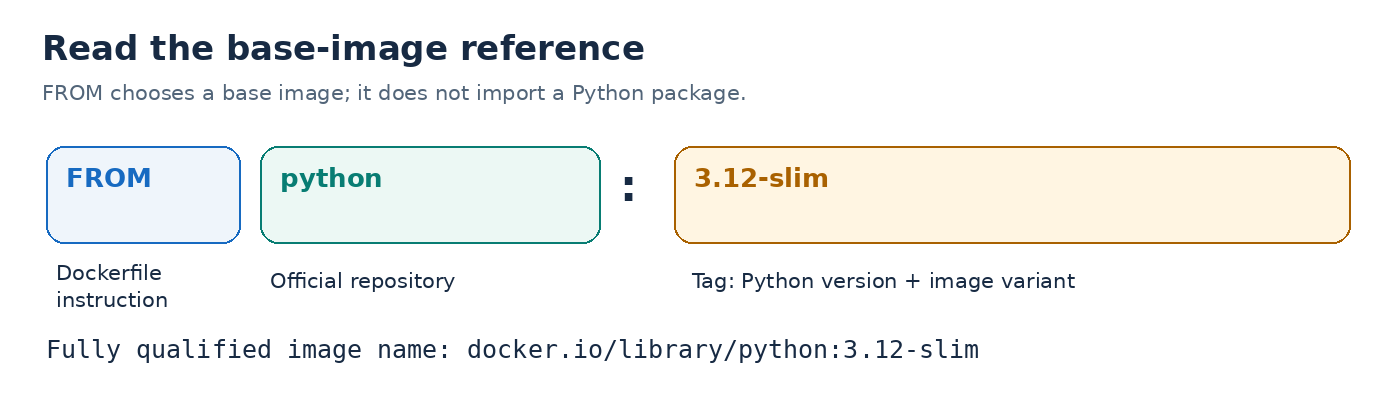

### Optional five-minute experiment: compare size and contents yourself

Pre-pull these images before class if bandwidth is limited. Tags and architectures
change the numbers, so **measure the images on this machine instead of memorizing MB values**.
All three commands download image content; none starts a persistent app container.

In [ ]:
# Download or refresh image python:3.12; this does not run a container.
# python is the Docker Official Image repository on Docker Hub; its tag selects a Python version
# and image variant for this machine's platform.
!docker pull python:3.12

In [ ]:
# Download or refresh image python:3.12-slim; this does not run a container.
# python is the Docker Official Image repository on Docker Hub; its tag selects a Python version
# and image variant for this machine's platform.
!docker pull python:3.12-slim

In [ ]:
# Download or refresh image python:3.12-alpine; this does not run a container.
# python is the Docker Official Image repository on Docker Hub; its tag selects a Python version
# and image variant for this machine's platform.
!docker pull python:3.12-alpine

In [ ]:
# List local images in repository python; its tags may share an image ID and layers. This does
# not pull or run images.
!docker image ls python

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# python:3.12-slim: the image reference used to create this container; the text after : is its
# tag.
# cat /etc/os-release: override CMD and print that file inside the container, then exit.
!docker run --rm python:3.12-slim cat /etc/os-release

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# python:3.12-alpine: the image reference used to create this container; the text after : is its
# tag.
# cat /etc/os-release: override CMD and print that file inside the container, then exit.
!docker run --rm python:3.12-alpine cat /etc/os-release

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# python:3.12: the image reference used to create this container; the text after : is its tag.
# sh -c: execute the quoted script inside the container; command -v finds gcc, and || echo
# prints an explanation if gcc is absent.
!docker run --rm python:3.12 sh -c "command -v gcc || echo 'gcc is not installed'"

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# python:3.12-slim: the image reference used to create this container; the text after : is its
# tag.
# sh -c: execute the quoted script inside the container; command -v finds gcc, and || echo
# prints an explanation if gcc is absent.
!docker run --rm python:3.12-slim sh -c "command -v gcc || echo 'gcc is not installed'"

**Observe:** compare the size column for the same machine/platform. The OS files
show Debian versus Alpine; the compiler check makes a content difference visible.
The fullest image commonly has `gcc`; slim normally requires adding build tools
when your own dependencies need them. Check the actual output on your images.

| Quantity | What a smaller image can change | What it does not guarantee |
|---|---|---|
| Image transfer | Fewer bytes to pull or push; less network time/cost when layers are missing | Faster transfers if everything is already cached |
| Stored layers | Less image storage and extraction work | A simple sum of all tag sizes: images may share layers |
| Deployment startup | Less time fetching/extracting missing layers can shorten a cold deployment | Faster application initialization after the image is present |
| Running app CPU / RAM | Must be measured for the actual workload | Lower CPU or RAM just because the image file is smaller |

An image stored on disk is not all loaded into RAM when a container starts.
Use `docker stats --no-stream` for runtime usage; the `--cpus` and `--memory` run
options control resource limits. Docker Hub's compressed/platform-specific size
and the local CLI's size accounting may differ. For shared/unique disk accounting,
inspect `docker system df -v` rather than adding every image row.

**Explain back:** if two containers run the same Python workload, does shrinking the
base image by 80% prove that they need 80% less RAM? No: image size and working memory
are different measurements.

References: [image listing and size](https://docs.docker.com/reference/cli/docker/image/ls/),
[disk-usage accounting](https://docs.docker.com/reference/cli/docker/system/df/),
[choosing a base image](https://docs.docker.com/build/building/best-practices/).

### 3.2 Write the Dockerfile

Each comment below describes the instruction immediately after it, including its
arguments. Read it once as a recipe, then run the cell to create the file.

**Create `Dockerfile`:** `%%writefile Dockerfile` below is Jupyter's file-writing
magic; it writes the remaining cell text verbatim into this file in the project
folder. It must be the cell's first line. To work in a terminal, create `Dockerfile`
in your editor and copy everything **after** that magic line.

In [ ]:
%%writefile Dockerfile
# Base this image on Docker Hub's official python repository, tag 3.12-slim: Python 3.12 plus a
# minimal Debian user-space environment. See the Hub links above.
FROM python:3.12-slim

# Set a default environment variable that prevents Python from writing .pyc cache files.
ENV PYTHONDONTWRITEBYTECODE=1
# Disable Python stdout/stderr buffering so container logs appear promptly.
ENV PYTHONUNBUFFERED=1

# Create/select /app inside the image; later relative RUN, COPY destinations, and CMD use this
# working directory.
WORKDIR /app

# Copy requirements.txt FROM the build-context folder TO the current image directory /app; the
# destination dot means /app.
COPY requirements.txt .
# During BUILD, install dependencies: --no-cache-dir avoids retaining pip's download cache in
# the image; -r reads the named requirements file. This is separate from Docker's layer cache.
RUN pip install --no-cache-dir -r requirements.txt

# Copy the current host app.py into /app in the image; put it after dependency installation so
# source-only changes can reuse that layer.
COPY app.py .

# Document the intended container port; EXPOSE does not publish a port on the host.
EXPOSE 8000

# At RUN time, default to python app.py; JSON exec form launches Python directly without a
# shell. docker run IMAGE COMMAND can override it.
CMD ["python", "app.py"]

| Instruction | What it means here |
|---|---|
| `FROM` | Start from an image containing Python and a Linux user-space environment |
| `ENV` | Set default environment variables in subsequent build steps and containers |
| `WORKDIR` | Set the working directory inside the image/container |
| First `COPY` | Put the dependency list into the image |
| `RUN` | Install packages **while building** |
| Second `COPY` | Put the current app source into the image |
| `EXPOSE 8000` | Document the intended container port; this does not publish it on the host |
| `CMD` | Set the default command for a container; this does not start the app during build |

Dependency installation precedes the app copy so edits to `app.py` can reuse the
dependency layer. The versions in `requirements.txt` pin our direct dependencies;
a full reproducible release would also lock transitive dependencies and base-image digests.

### 3.3 Limit the build context

`.dockerignore` excludes matching files from the build context. Keep local data,
venvs, notebooks, and credential files out. Our Dockerfile also copies only the two
files it needs.

**Create `.dockerignore`:** `%%writefile .dockerignore` below is Jupyter's file-writing
magic; it writes the remaining cell text verbatim into this file in the project
folder. It must be the cell's first line. To work in a terminal, create `.dockerignore`
in your editor and copy everything **after** that magic line.

In [ ]:
%%writefile .dockerignore
# Exclude repository history from the build context.
.git
# Exclude the local environment file, which may contain credentials.
.env
# Exclude a common local virtual-environment directory.
.venv
# Exclude the alternate common virtual-environment directory name.
venv
# Exclude local Python bytecode cache directories.
__pycache__
# Exclude matching compiled Python bytecode files.
*.pyc
# Exclude matching Jupyter notebooks; the app does not need teaching materials in its image.
*.ipynb
# Exclude Jupyter checkpoint files.
.ipynb_checkpoints
# Exclude live counter data; runtime storage belongs outside the app image.
host-data
# Exclude the host configuration folder used in the bind-mount exercise.
host-config
# Exclude archive files matching this pattern.
*.tar

### 3.4 Build the image — this does not run the server

`-t porter:1.0` assigns a repository name and tag. The final `.` is the **build
context**, the current folder. Docker finds `Dockerfile` there by default.

In [ ]:
# Build an image from Dockerfile; this does not start the app server.
# -t porter:1.0: tag the built image; here -t means tag, not terminal.
# .: send this directory as the build context; COPY source paths are relative to it.
!docker build -t porter:1.0 .

In [ ]:
# List local images in repository porter; its tags may share an image ID and layers. This does
# not pull or run images.
!docker image ls porter

In [ ]:
# List running containers.
!docker ps

**Observe:** the image exists, but building did not leave an app container running.
Build tools may use temporary execution environments for build steps; these are
different from starting your application service.

### 3.5 Build again and inspect caching

In [ ]:
# Build an image from Dockerfile; this does not start the app server.
# --progress=plain: show ordinary build-log lines so cached steps are easy to inspect.
# -t porter:1.0: tag the built image; here -t means tag, not terminal.
# .: send this directory as the build context; COPY source paths are relative to it.
!docker build --progress=plain -t porter:1.0 .

In [ ]:
# Show the build history of porter:1.0; inspect instructions, layer sizes, and metadata-only
# entries.
!docker image history porter:1.0

**Predict before running:** If only `app.py` changes, should the `pip install` layer need to run again?

<details>
<summary>Reveal the explanation</summary>

Normally no: the dependency file and earlier inputs did not change. The app-copy step and later dependent steps change. If requirements.txt changes, package installation and following steps need rebuilding.

</details>

An image is a snapshot. Editing the host's `app.py` does not change an existing
image or automatically replace an existing container. We will contrast that with
bind mounts later.

## 4 · Run modes: foreground, interactive, detached

**Build an image; choose a mode when running a container.** There is no
“interactive image build” or “detached image build” corresponding to `run -it` or `run -d`.
The `-t` in `docker build -t` means **tag**; the `-t` in `docker run -it` means **TTY**.

| Mode | Command shape | What you see | Where to run |
|---|---|---|---|
| Foreground server | `docker run IMAGE` | Server logs occupy your terminal | Terminal |
| Interactive shell | `docker run -it IMAGE sh` | A prompt inside a new container | Terminal |
| Detached server | `docker run -d IMAGE` | Container ID; prompt returns | Notebook or terminal |

These flags are separate concepts: `-i` keeps standard input open; `-t` allocates a
pseudo-terminal; `-d` detaches the CLI. A foreground process does not necessarily
need interactive input. Detached containers also stop if their main process exits.

### Read the complete run command as fields

| Token in `docker run -d --name porter -p 127.0.0.1:8000:8000 porter:1.0` | Role |
|---|---|
| `docker run` | Create and start a new container |
| `-d` | Detach the CLI from the app process |
| `--name porter` | Give the container a name |
| `-p 127.0.0.1:8000:8000` | Publish a host address/port to the container port |
| `porter:1.0` | Choose the image repository and tag |
| No trailing command | Use the image's default CMD |

Compare the different uses of the same short flag:

| Context | Meaning |
|---|---|
| `docker build -t porter:1.0 .` | `-t` assigns an image tag |
| `docker run -it porter:1.0 sh` | `-t` allocates a TTY; `-i` keeps stdin open |
| `docker run -v mydata:/data ...` | `-v` configures a mount |
| `docker system df -v` | `-v` requests verbose disk-usage details |

Read flags in the context of their subcommand. The argument after the image in
`docker run ... porter:1.0 sh` is an in-container command that overrides CMD.

### Port mapping: the browser uses the host-side port

This illustration uses **8080:8000** to make the two sides visibly different.
The standalone commands below use **8000:8000**; the Compose lesson later uses
**8080:8000**. Always use the host port from the command you actually ran.

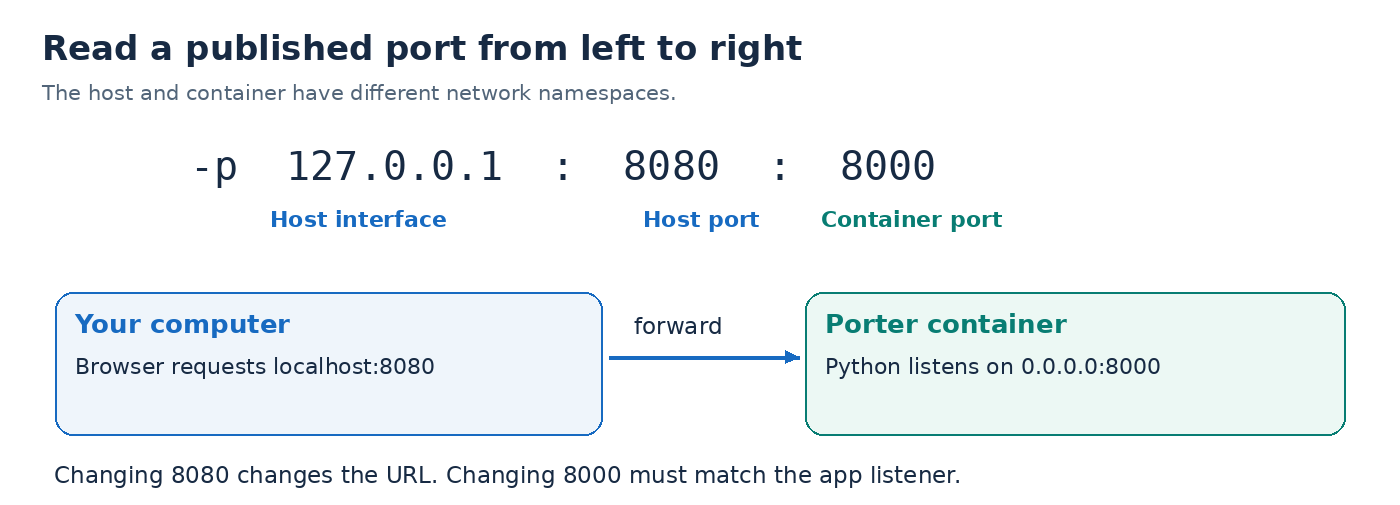

### 4.1 Foreground server — TERMINAL ONLY

```bash
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# --name porter-fg: assign this container a name for later logs, exec, stop, and rm commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
docker run --rm --name porter-fg -p 127.0.0.1:8000:8000 porter:1.0
```

Open [http://localhost:8000](http://localhost:8000). Visit it again and observe the
request logs. The count does not increase on GET; `/visit` uses POST deliberately.

Press **Ctrl+C** to stop the app, then continue. `--rm` removes `porter-fg` after exit.
If the terminal remains attached, use `docker stop porter-fg` in a second terminal.

`-p 127.0.0.1:8000:8000` maps **host loopback port 8000 → container port 8000**.
The app listens on `0.0.0.0` *inside* the container so this mapping can reach it.

### 4.2 Interactive shell — TERMINAL ONLY

```bash
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# -i: keep standard input open; -t: allocate a terminal for an interactive shell. Use a real
# terminal.
# --name porter-shell: assign this container a name for later logs, exec, stop, and rm commands.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# sh: override the app CMD with a shell; no web server starts in this container.
docker run --rm -it --name porter-shell porter:1.0 sh
```

Then run these **inside the container's shell**:

```sh
# Print the working directory inside this container shell.
pwd
# List the files in the container shell's current directory.
ls
# Run the container's Python interpreter; --version prints its version and exits.
python --version
# Print the dependency file from the current directory inside the container.
cat requirements.txt
# Leave this shell; if it is the container's main process, the container stops.
exit
```

The command `sh` overrides the image's `CMD ["python", "app.py"]`, so this
container runs a shell instead of the web server. No published port is needed.
`exit` ends the main shell, and `--rm` removes the container.

**Notebook equivalent for inspecting files without an interactive shell:**

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# ls /app: override CMD and list that container directory, then exit.
!docker run --rm porter:1.0 ls /app

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# python --version: override the image's CMD, print its Python version, then exit.
!docker run --rm porter:1.0 python --version

### 4.3 Detached server — NOTEBOOK OR TERMINAL

Make sure the foreground experiment is stopped. This time omit `--rm` so we can
study a stopped container. The first run creates the container named `porter`.

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter: assign this container a name for later logs, exec, stop, and rm commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
!docker run -d --name porter -p 127.0.0.1:8000:8000 porter:1.0

Docker returns before the server necessarily finishes starting. This health request
retries connection refusals for a short time; initial connection errors are normal.

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8000/

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8000/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8000/visit

In [ ]:
# List running containers.
!docker ps

In [ ]:
# Read stdout/stderr logs from container porter.
# --tail 5: show only that many final log lines.
!docker logs --tail 5 porter

**Predict before running:** If you close the terminal that ran `docker run -d`, must Porter stop?

<details>
<summary>Reveal the explanation</summary>

No. The daemon manages the detached container independently of that CLI session. Closing Docker Desktop or stopping the Docker daemon is a different event.

</details>

## 5 · Inspect, execute, stop, start, remove

### 5.1 Run another command inside the existing container

`exec` starts an additional process in a **running** container. It does not create
a new container and does not replace Porter's main server process.

In [ ]:
# Run an additional process INSIDE an existing running container; do not create a new container.
# porter: the existing container name, not an image tag.
# python --version: print the interpreter version inside this running container.
!docker exec porter python --version

In [ ]:
# Run an additional process INSIDE an existing running container; do not create a new container.
# porter: the existing container name, not an image tag.
# cat /data/counter.txt: read that path inside the container; mounted paths read from their
# backing storage.
!docker exec porter cat /data/counter.txt

In [ ]:
# Show host-port mappings for container porter; compare host ports with its internal listening
# port.
!docker port porter

In [ ]:
# Show CPU, memory, and other usage for running container porter.
# --no-stream: take one snapshot, then exit instead of keeping the notebook cell busy.
!docker stats --no-stream porter

For an interactive debugging shell, use a terminal:

```bash
# Run an additional process INSIDE an existing running container; do not create a new container.
# -i: keep stdin open; -t: allocate an interactive terminal. Run this in your terminal.
# porter: the existing container name, not an image tag.
# sh: open an extra shell; exiting it leaves the app's main process running.
docker exec -it porter sh
```

Type `exit` to leave this extra shell. Porter keeps running because the server is
still the container's main process. `docker run -it ... sh` and `docker exec -it ... sh`
therefore have different lifecycles.

To follow logs in a terminal:

```bash
# Read stdout/stderr logs from container porter.
# --tail 5: show only that many final log lines.
# --follow: stream future log lines until Ctrl+C; stopping this log viewer does not stop the
# app.
docker logs --follow --tail 5 porter
```

Ctrl+C stops **following logs**. It does not stop Porter. The plain `--tail` cells
in this notebook terminate automatically.

### 5.2 Stop and start the same container

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter: the container name targeted by this operation.
!docker stop porter

In [ ]:
# -a: include stopped containers as well as running ones.
# --filter name=porter: restrict rows to matching container names; name matching can include
# more than one lab container.
!docker ps -a --filter name=porter

In [ ]:
# Start this existing stopped container using its original settings; do not create a
# replacement.
# porter: the container name targeted by this operation.
!docker start porter

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8000/

**Observe:** the count survives. Stopping did not remove this container's writable
layer. `start` restarts the existing container with its original configuration;
it does not build a new image or apply new `run` flags.

### 5.3 Stop and remove this container

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter: the container name targeted by this operation.
!docker stop porter

In [ ]:
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter: the container name targeted by this operation.
!docker rm porter

In [ ]:
# List local images in repository porter; its tags may share an image ID and layers. This does
# not pull or run images.
!docker image ls porter

The image still exists. Removing this container removed its private writable layer,
including the unmounted counter file. Removing a container and removing an image
are separate operations.

| Command | Creates a new container? | Requires an existing container? |
|---|---:|---:|
| `docker run` | Yes | No |
| `docker start` | No | Yes, stopped |
| `docker exec` | No | Yes, running |
| `docker stop` | No | Yes, running |
| `docker rm` | No | Yes; normally stopped |

## 6 · Tag, push, and pull

### 6.1 Add another local tag

A tag is a reference to an image. Adding a tag does not rebuild or duplicate all
the layers. Compare the image IDs below.

In [ ]:
# Add a local image reference without rebuilding or duplicating all its layers.
# porter:1.0: existing source image; porter:demo: new repository/name:tag reference.
# Compare image IDs afterwards: both tags should point to the same image.
!docker tag porter:1.0 porter:demo

In [ ]:
# List local images in repository porter; its tags may share an image ID and layers. This does
# not pull or run images.
!docker image ls porter

**Observe:** `porter:1.0` and `porter:demo` should have the same image ID at this point.
Tags can later be moved to different images. `latest` is also just a tag name; it
does not automatically find the newest version.

### 6.2 Publish to Docker Hub — OPTIONAL, requires your account

Create a repository named `porter` in your Docker Hub namespace. Choose its
visibility deliberately. Throughout the **next four code cells**, replace
`your-dockerhub-username` with your actual lowercase namespace before running.
The literal placeholder is not a usable shared workshop account.

Log in **in your terminal**:

```bash
# Authenticate to Docker Hub in a terminal; follow the browser flow or secure prompt. Do not
# store credentials in this notebook.
docker login
```

Follow the browser/device flow if prompted. If using username login instead, run
`docker login --username YOUR_USERNAME` and enter an access token at the prompt.
Keep credentials out of notebook cells and saved output.

`namespace/repository:tag` tells Docker which registry repository to use. With no
registry hostname supplied, these commands use Docker Hub.

In [ ]:
# Add a local image reference without rebuilding or duplicating all its layers.
# porter:1.0: existing source image; your-dockerhub-username/porter:1.0: new repository/name:tag
# reference.
# Replace your-dockerhub-username with your own namespace before running.
!docker tag porter:1.0 your-dockerhub-username/porter:1.0

In [ ]:
# Upload missing layers and the image manifest for image your-dockerhub-username/porter:1.0;
# this does not run a container.
# Replace the namespace first; Docker Hub is used because no registry hostname is supplied.
# Pushing requires login and repository permission.
!docker push your-dockerhub-username/porter:1.0

**Observe:** push uploads missing image layers and the manifest, then reports a
digest. Open your Hub repository and find the `1.0` tag. A push distributes the
image; it does not launch a server on Docker Hub.

### 6.3 Pull and run the published image

These also work on a second compatible computer with Docker, without this source
folder. A private repository requires login with pull access on that computer.
On your original computer, cached layers may already be present; `pull` may simply
confirm they are up to date.

In [ ]:
# Download or refresh image your-dockerhub-username/porter:1.0; this does not run a container.
# Replace the namespace first; Docker Hub is used because no registry hostname is supplied.
# Pushing requires login and repository permission.
!docker pull your-dockerhub-username/porter:1.0

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# your-dockerhub-username/porter:1.0: the image reference used to create this container; the
# text after : is its tag.
# python --version: override the image's CMD, print its Python version, then exit.
!docker run --rm your-dockerhub-username/porter:1.0 python --version

**Predict before running:** Would pushing the image also upload the visit count from a running container or a mounted volume?

<details>
<summary>Reveal the explanation</summary>

No. Push uploads the image, not container runtime changes or external mounts. Distributing an image and backing up application data are separate tasks.

</details>

The remaining experiments use **`porter:1.0`** so they also work if publishing was
skipped. After a pull, that published image could be used in exactly the same
`docker run --mount ...` commands. Storage is configured when creating containers;
it does not require rebuilding or pushing the image.

## 7 · What disappears when a container is removed?

First, establish a baseline with **no mount**. Keep the distinction precise:
container files usually survive **stop/start**, but the private writable layer
does not survive **container removal**.

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter-ephemeral: assign this container a name for later logs, exec, stop, and rm
# commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
!docker run -d --name porter-ephemeral -p 127.0.0.1:8000:8000 porter:1.0

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8000/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8000/visit

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8000/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8000/visit

In [ ]:
# Run an additional process INSIDE an existing running container; do not create a new container.
# porter-ephemeral: the existing container name, not an image tag.
# cat /data/counter.txt: read that path inside the container; mounted paths read from their
# backing storage.
!docker exec porter-ephemeral cat /data/counter.txt

**Observe:** after exactly these two POST requests, the file contains `2`. Now
remove the container and create a fresh one from the same image and with the same name.

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter-ephemeral: the container name targeted by this operation.
!docker stop porter-ephemeral

In [ ]:
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter-ephemeral: the container name targeted by this operation.
!docker rm porter-ephemeral

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter-ephemeral: assign this container a name for later logs, exec, stop, and rm
# commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
!docker run -d --name porter-ephemeral -p 127.0.0.1:8000:8000 porter:1.0

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8000/

**Observe:** `visits` is back to `0`. Reusing a name did not recover the removed
container's filesystem. The original image never included that counter file.
Stop and remove this replacement before the next experiment uses port 8000.

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter-ephemeral: the container name targeted by this operation.
!docker stop porter-ephemeral

In [ ]:
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter-ephemeral: the container name targeted by this operation.
!docker rm porter-ephemeral

## 8 · Named volumes: Docker manages the storage location

### 8.1 Create and attach a volume

A **named volume** has a lifecycle separate from the container. Docker manages its
location; the app still sees an ordinary path, `/data`. On Docker Desktop its storage
is normally inside Docker's Linux VM, not a folder beside this notebook.

In [ ]:
# Create Docker-managed volume porter-data, or reuse it if it already exists; this does not
# erase its old contents.
!docker volume create porter-data

In [ ]:
# Show metadata for volume porter-data; its Mountpoint belongs to the Docker daemon host, which
# may be Desktop's Linux VM.
!docker volume inspect porter-data

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter-volume: assign this container a name for later logs, exec, stop, and rm
# commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# --mount: type=volume selects Docker-managed named storage; source=porter-data is the volume
# name; target=/data is the path inside this container.
# No readonly option: this mount permits container reads and writes.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
!docker run -d --name porter-volume -p 127.0.0.1:8000:8000 --mount type=volume,source=porter-data,target=/data porter:1.0

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8000/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8000/visit

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8000/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8000/visit

In [ ]:
# Run an additional process INSIDE an existing running container; do not create a new container.
# porter-volume: the existing container name, not an image tag.
# cat /data/counter.txt: read that path inside the container; mounted paths read from their
# backing storage.
!docker exec porter-volume cat /data/counter.txt

**Record the count.** It is `2` with a fresh volume and exactly two POSTs; a reused
volume may already contain visits. Creating an already-existing named volume does
not reset it.

`type=volume` chooses a named volume, `source=porter-data` chooses its name, and
`target=/data` chooses the path inside the container. The shorter equivalent is
`-v porter-data:/data`. These are alternative spellings, not two mounts to add together.

### 8.2 Replace the container; reuse the same volume

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter-volume: the container name targeted by this operation.
!docker stop porter-volume

In [ ]:
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter-volume: the container name targeted by this operation.
!docker rm porter-volume

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter-volume: assign this container a name for later logs, exec, stop, and rm
# commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# --mount: type=volume selects Docker-managed named storage; source=porter-data is the volume
# name; target=/data is the path inside this container.
# No readonly option: this mount permits container reads and writes.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
!docker run -d --name porter-volume -p 127.0.0.1:8000:8000 --mount type=volume,source=porter-data,target=/data porter:1.0

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8000/

**Predict before running:** Why did the count survive even though this is a new container?

<details>
<summary>Reveal the explanation</summary>

The application writes under /data, which is a mount of porter-data. Those bytes live outside the removed container layer. The new container mounts the same volume and reads them.

</details>

### 8.3 Inspect the volume with a temporary, read-only helper container

This is useful on Docker Desktop, where manually opening the daemon's storage
directory is not the normal workflow. The helper uses the same volume at a
different container path.

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# --mount: type=volume selects Docker-managed named storage; source=porter-data is the volume
# name; target=/saved is the path inside this container.
# readonly: the container can read this mount but cannot modify it.
# python:3.12-slim: the image reference used to create this container; the text after : is its
# tag.
# cat /saved/counter.txt: override CMD and print that file inside the container, then exit.
!docker run --rm --mount type=volume,source=porter-data,target=/saved,readonly python:3.12-slim cat /saved/counter.txt

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter-volume: the container name targeted by this operation.
!docker stop porter-volume

In [ ]:
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter-volume: the container name targeted by this operation.
!docker rm porter-volume

`porter-data` still exists. We will remove it only in the explicit cleanup section.
Volumes persist independently, but they are not automatic backups and are not
included in registry pushes.

## 9 · Bind mounts: choose an actual host path

Use a bind mount when you want a specific host folder or file to appear in the
container: project source, configuration, datasets, or generated output.

### Read the mount: volume name versus host path

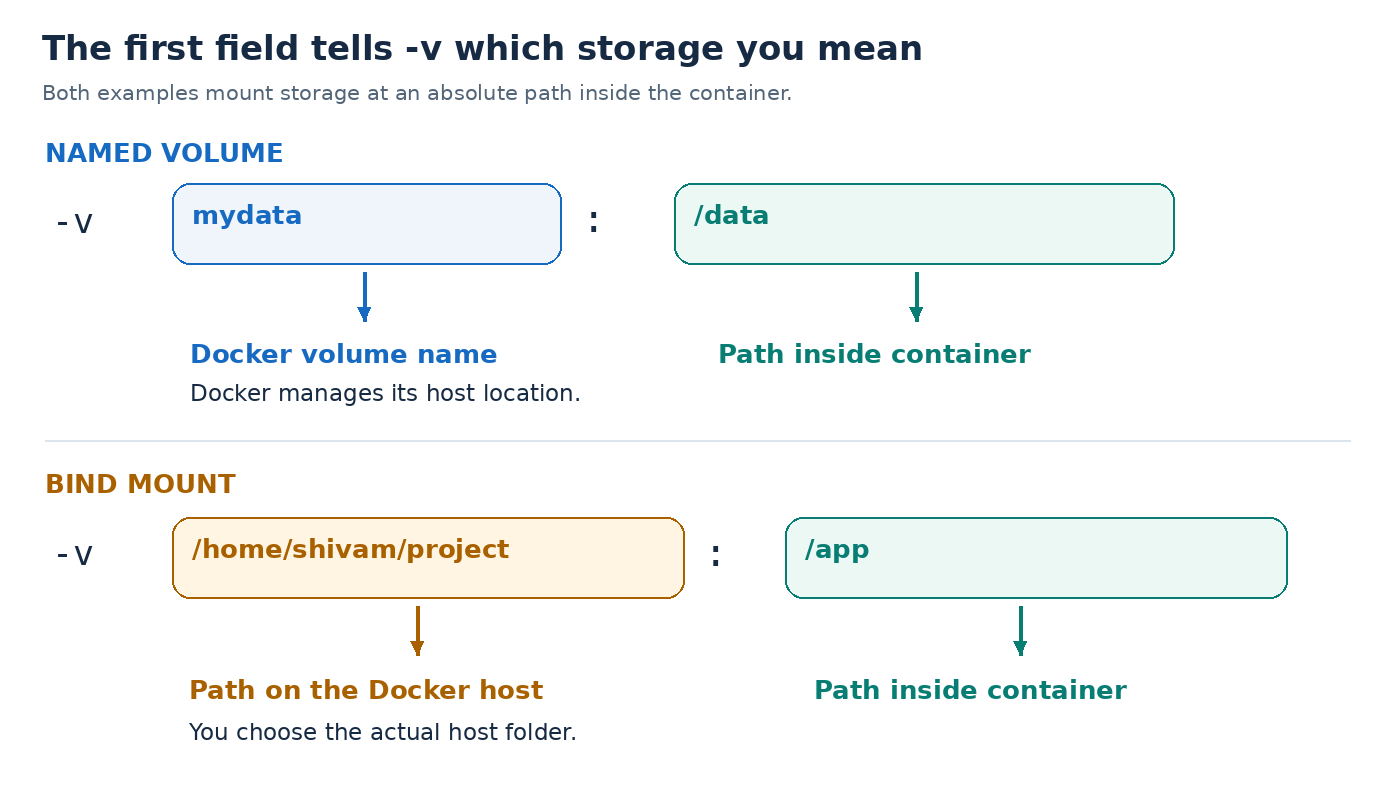

### Why the same `-v` option can mean two different mounts

In the two-field form **`-v SOURCE:CONTAINER_PATH`**, Docker distinguishes a volume
name from a host filesystem path in `SOURCE`. The destination is always a path
inside the container. An optional third field such as `:ro` makes access read-only.

| Argument | First field means | Second field means | Mount type |
|---|---|---|---|
| `-v mydata:/data` | Docker volume named `mydata` | `/data` inside the container | Named volume |
| `-v /home/shivam/project:/app` | Explicit path on the Docker host | `/app` inside the container | Bind mount |
| `-v ./mydata:/data` | Directory `mydata` under the current host folder | `/data` inside the container | Bind mount |
| `-v mydata:/data:ro` | Docker volume named `mydata` | `/data`, read-only for the container | Named volume |

**The easy-to-miss difference:** `mydata` and `./mydata` are not interchangeable.
Even if a host directory named `mydata` exists, the bare source name requests a
Docker volume. The `./` explicitly makes it a host path. `/home/shivam/project` is
an illustrative Linux path, not a directory this notebook creates.

Our lab's commands use **`--mount`**, which states the type explicitly:

| Short form in this lab | Explicit equivalent |
|---|---|
| `-v porter-data:/data` | `--mount type=volume,source=porter-data,target=/data` |
| `-v ./host-data:/data` | `--mount type=bind,source=./host-data,target=/data` |
| `-v ./host-config:/config:ro` | `--mount type=bind,source=./host-config,target=/config,readonly` |

With `--mount`, `type=volume` or `type=bind` expresses the choice directly. The
`source` is outside the container; `target`/`destination` is inside it. Mounting
does not mean copying the directory into the image.

**Missing source directories:** bind mounts using `--mount` normally fail if the
host source does not exist; `-v` can create a missing source as a directory, which
can hide a typo. We create our host folders first. On Windows, use the matching
Windows/WSL path convention and quote arguments containing spaces.

Source: [Docker bind-mount syntax](https://docs.docker.com/engine/storage/bind-mounts/).

Here we mount two host directories:

| Host source, relative to the project folder | Container path | Access | Purpose |
|---|---|---|---|
| `./host-data` | `/data` | Read/write | Counter file visible in the host folder |
| `./host-config` | `/config` | Read-only | Banner edited on the host |

These host paths must exist before `--mount` runs. A bind mount uses paths on the
**Docker host**; the following assumes the local setup from Section 0.

In [ ]:
# Create the bind-mount data source before docker run; reuse an existing folder without deleting
# data.
Path("host-data").mkdir(exist_ok=True)
# Create the host configuration folder that will be mounted read-only inside the container.
Path("host-config").mkdir(exist_ok=True)
# Print the absolute host data path for use if a relative mount path is rejected.
print("Host data:", Path("host-data").resolve())
# Print the absolute host configuration path; it is different from the container path /config.
print("Host config:", Path("host-config").resolve())

In [ ]:
# Overwrite the host banner file with this exact text; write_text writes the file and
# encoding="utf-8" sets its character encoding. The running app rereads this file on each
# request.
Path("host-config/banner.txt").write_text("Hello from a file on my laptop!\n", encoding="utf-8")

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter-bind: assign this container a name for later logs, exec, stop, and rm commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# --mount: type=bind selects a path on the Docker host; source=./host-data is the host path;
# target=/data is the path inside this container.
# No readonly option: this mount permits container reads and writes.
# --mount: type=bind selects a path on the Docker host; source=./host-config is the host path;
# target=/config is the path inside this container.
# readonly: the container can read this mount but cannot modify it.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
!docker run -d --name porter-bind -p 127.0.0.1:8000:8000 --mount "type=bind,source=./host-data,target=/data" --mount "type=bind,source=./host-config,target=/config,readonly" porter:1.0

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8000/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8000/

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8000/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8000/visit

### 9.1 A container write appears on the host

Open `host-data/counter.txt` in your editor, or run this notebook-only read cell.
No `docker cp` command is required: the mount is the connection.

In [ ]:
# Read the counter file directly from the host folder to verify that the container wrote through
# the bind mount.
print(Path("host-data/counter.txt").read_text())

### 9.2 A host edit appears inside the running container

Change the banner by executing this file-writing cell. Then fetch the response again.

In [ ]:
# Overwrite the host banner file with this exact text; write_text writes the file and
# encoding="utf-8" sets its character encoding. The running app rereads this file on each
# request.
Path("host-config/banner.txt").write_text("I changed this on the host. No rebuild needed.\n", encoding="utf-8")

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8000/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8000/

In [ ]:
# Run an additional process INSIDE an existing running container; do not create a new container.
# porter-bind: the existing container name, not an image tag.
# cat /config/banner.txt: read that path inside the container; mounted paths read from their
# backing storage.
!docker exec porter-bind cat /config/banner.txt

**Predict before running:** Does a bind mount automatically make every program reload changed code?

<details>
<summary>Reveal the explanation</summary>

No. It makes the new file contents visible. Our app reads banner.txt on every request, so the new text appears immediately. Already-imported Python code generally needs a process restart or a development reloader.

</details>

`readonly` prevents writes **from the container** to `/config`. You can still edit
the original file on the host. The `/data` mount is read/write.

Optional deliberate failure, run in a terminal while Porter is still running:

```bash
# Run an additional process INSIDE an existing running container; do not create a new container.
# porter-bind: the existing container name, not an image tag.
# sh -c: run the quoted script inside the container; echo plus > tries to write a file on the
# read-only /config mount and should fail.
docker exec porter-bind sh -c "echo blocked > /config/from-container.txt"
```

Expect a read-only-filesystem error. The shell and redirection execute **inside**
the container because they follow `sh -c`.

### 9.3 Remove the container; inspect the surviving host file

In [ ]:
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter-bind: the container name targeted by this operation.
!docker stop porter-bind

In [ ]:
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter-bind: the container name targeted by this operation.
!docker rm porter-bind

In [ ]:
# Read the host file after container removal; the file survives because it belongs to the host
# directory.
print("Still on the host:", Path("host-data/counter.txt").read_text())

### Storage decision table

| Storage | Where data belongs | Survives container removal? | Typical use |
|---|---|---:|---|
| Writable container layer | This container instance | No | Disposable runtime files |
| Named volume | Docker-managed storage | Yes, until the volume is removed | Database data |
| Bind mount | A chosen host path | Yes, until the host files are removed | Source, config, host-visible output |

**Mounts can hide image contents.** Mounting a host folder at `/app` obscures the
image's original `/app` while the mount is present; it does not merge the two folders.
An empty named volume has different initial-copy behavior when mounted over image
data, so do not use the “folders merge” model for either kind of mount.

**Path fallback:** if your CLI rejects a relative bind source, replace `./host-data`
and `./host-config` with the absolute paths printed above. Keep the full mount
argument double-quoted, especially if the path contains spaces. Native Windows
paths such as `C:/Users/you/docker_porter_lab/host-data` work with Docker Desktop;
avoid mixing Windows and WSL path conventions in the same shell.

## 10 · Why Docker Compose?

So far, one `docker run` command described one app container. Suppose Porter now
uses Redis. We need two containers, a network, a connection address, a data volume,
port publication, and readiness checks. The commands are possible by hand, but
every learner would have to keep their options consistent.

**Compose stores this application's runtime configuration in one YAML file.**
The Dockerfile still describes how to build the Porter image; Compose describes
how Porter and Redis are configured and connected.

| Part of our application | How it will be addressed |
|---|---|
| Browser or host curl → Porter | `http://localhost:8080` |
| Porter's container listener | Port `8000` |
| Porter → Redis on the Compose network | `redis:6379` |
| Persistent Redis files | Named volume `redis-data` mounted at Redis's `/data` |

`localhost` **inside Porter** means Porter itself. It is not the Redis container.
Compose provides service-name DNS on its default project network. We do not need
to publish Redis's port to the host for these containers to communicate.

### Visual model: requests, the service network, and persistent data

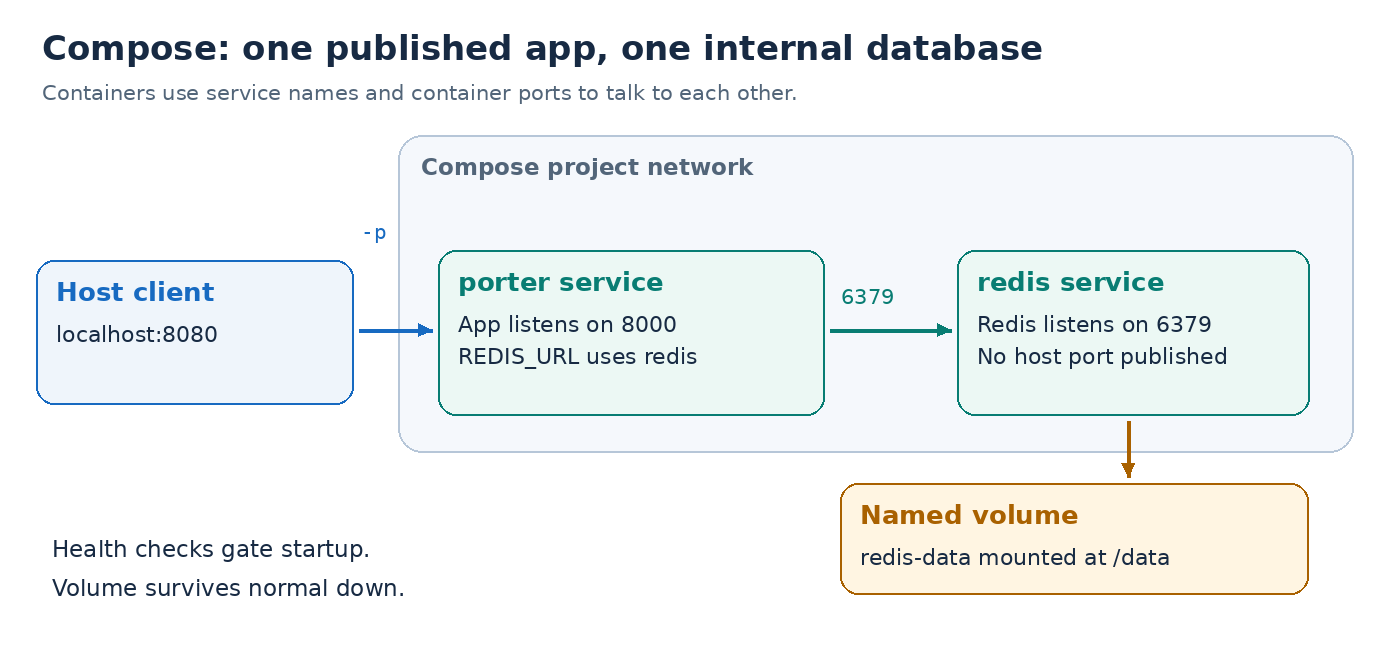

### 10.1 Define two services

Porter uses the image built earlier and switches storage via `REDIS_URL`.
The previous file counter is **not migrated** to Redis; this is a new backend with
its own data. Redis uses append-only persistence and its own named volume.

**Create `compose.yaml`:** `%%writefile compose.yaml` below is Jupyter's file-writing
magic; it writes the remaining cell text verbatim into this file in the project
folder. It must be the cell's first line. To work in a terminal, create `compose.yaml`
in your editor and copy everything **after** that magic line.

In [ ]:
%%writefile compose.yaml
# Set the project name used to group this lab's containers, network, and volumes.
name: porter-workshop

# Begin the map of application services; each service describes its container configuration.
services:
  # Name the Python web-app service porter; Compose commands address it using this name.
  porter:
    # Use this project directory as build context and its Dockerfile as the recipe for Porter.
    build: .
    # Name/tag the resulting locally built app image porter:1.0.
    image: porter:1.0
    # Declare host-to-container port publications for the app service.
    ports:
      # Bind host loopback 127.0.0.1, host port 8080, to container port 8000; keep this value
      # quoted.
      - "127.0.0.1:8080:8000"
    # Pass the following variables into the created app container; they do not modify the image.
    environment:
      # Use the redis protocol, service hostname redis, container port 6379, and Redis logical
      # database 0.
      REDIS_URL: redis://redis:6379/0
      # Set the greeting used when no /config/banner.txt overrides it.
      APP_MESSAGE: Hello from Compose
    # Describe services Porter depends on during startup.
    depends_on:
      # Select Redis as the dependency whose health Porter will wait for.
      redis:
        # Wait for the Redis health check to pass before starting Porter.
        condition: service_healthy
    # Define a bounded command that reports whether the porter service is ready.
    healthcheck:
      # CMD executes without a shell; python -c runs the code string. It GETs this container's
      # /health endpoint, with a two-second HTTP timeout; failure gives a nonzero exit.
      test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://127.0.0.1:8000/health', timeout=2)"]
      # Run the health check every three seconds after the startup period.
      interval: 3s
      # Treat an individual health-check command taking over three seconds as failed.
      timeout: 3s
      # Mark the container unhealthy after ten consecutive counted health-check failures.
      retries: 10
      # Give startup a five-second grace period during which failures normally do not count
      # toward retries.
      start_period: 5s

  # Name the separate database service redis; this name is also its DNS hostname on the Compose
  # network.
  redis:
    # Pull the Redis 7.4 Alpine image; it contains the Redis server, separate from the Python
    # client installed in Porter.
    image: redis:7.4-alpine
    # Override Redis's default command: --appendonly yes enables the append-only log;
    # --appendfsync always flushes every write for this small durability demo.
    command: ["redis-server", "--appendonly", "yes", "--appendfsync", "always"]
    # Attach persistent storage to this Redis service container.
    volumes:
      # Mount the named volume redis-data at /data INSIDE Redis, where its persistence files are
      # written.
      - redis-data:/data
    # Define a bounded command that reports whether the redis service is ready.
    healthcheck:
      # Execute redis-cli ping without a shell; a successful local Redis response makes this
      # check pass.
      test: ["CMD", "redis-cli", "ping"]
      # Run the Redis health check every two seconds.
      interval: 2s
      # Fail an individual Redis health-check command if it takes over two seconds.
      timeout: 2s
      # Mark Redis unhealthy after fifteen consecutive failed checks.
      retries: 15

# Declare project-level named volumes that can outlive the containers.
volumes:
  # Declare a Docker-managed named volume; Compose normally prefixes its actual name with the
  # project name.
  redis-data:

### Read the configuration

| YAML item | Meaning |
|---|---|
| `name` | Give this lab a consistent project name |
| `services.porter` | A service name used by Compose commands |
| `build: .` | Build Porter using this folder's Dockerfile |
| `image: porter:1.0` | Name/tag for that built image |
| `ports` | Publish the app on host port 8080 |
| `environment` | Configure this container when it is created |
| `depends_on` + `service_healthy` | Wait for Redis's health check before starting Porter |
| `healthcheck` | A command whose success reports service health |
| Redis `command` | Enable append-only persistence; flush each write for this small demo |
| `volumes` under Redis | Mount the named volume at the directory Redis writes to |
| Top-level `volumes` | Declare the volume Compose manages for the project |

`depends_on` alone controls startup ordering; it is not a general guarantee of
readiness. The health condition adds readiness at startup. The app still needs to
handle a database becoming unavailable later. Our app returns HTTP 503 for Redis
connection failures and can recover on a later request when Redis returns.

The frequent Redis flush policy keeps this tiny persistence demo predictable;
production durability/performance settings should be chosen for the workload.
The development server and unauthenticated internal Redis are teaching choices.

### 10.2 Validate the file, then build without starting

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Validate and display the resolved Compose configuration without starting containers.
!docker compose config

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Build service images that have a build section; do not start the services.
!docker compose build

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# List this Compose project's containers and their current status; -a, if present, also includes
# stopped containers.
!docker compose ps

**Observe:** the configuration expands successfully; the image builds. No services
have been started by `compose build`. If `compose ps` lists earlier lab services,
they are from a previous run of this same project.

### 10.3 Foreground Compose — TERMINAL ONLY

```bash
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Create/start the application and reconcile changed configuration or images with existing
# containers.
# No -d: attach to combined logs in the foreground; Ctrl+C stops these services.
docker compose up
```

Watch both services' logs. Open [http://localhost:8080](http://localhost:8080), then
press **Ctrl+C** to stop the foreground application before continuing. Compose
keeps the stopped containers; it has not removed the named volume.

### 10.4 Detached Compose — NOTEBOOK OR TERMINAL

This starts the services and waits up to 60 seconds for the defined health checks.
`--wait` implies detached execution; `-d` is included to make the mode explicit.

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Create/start the application and reconcile changed configuration or images with existing
# containers.
# -d: detach, so services keep running after the command returns.
# --wait: wait for services to be running/healthy; this also implies detached mode.
# --wait-timeout 60: stop waiting after 60 seconds if readiness is not reached.
!docker compose up -d --wait --wait-timeout 60

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# List this Compose project's containers and their current status; -a, if present, also includes
# stopped containers.
!docker compose ps

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8080/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8080/

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8080/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8080/visit

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# -X POST: send a POST request, which adds one visit in our app.
# http://localhost:8080/visit: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS -X POST http://localhost:8080/visit

**Observe:** `backend` is now `redis`. With a fresh Redis volume, two POSTs produce
a count of `2`. Existing Redis data is preserved on a repeat run.

### 10.5 The exact log command from the class example

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Read service stdout/stderr; the final argument selects which service's logs to show.
# --tail 5: show only the final five log lines for the selected service.
# porter: target only this service, rather than every service in the project.
!docker compose logs --tail 5 porter

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Read service stdout/stderr; the final argument selects which service's logs to show.
# --tail 5: show only the final five log lines for the selected service.
# redis: target only this service, rather than every service in the project.
!docker compose logs --tail 5 redis

Here `porter` is the **Compose service name**, not necessarily the actual container
name. Compose generates names such as `porter-workshop-porter-1`. Use service names
with `docker compose ...`; use actual container names/IDs with plain `docker ...`.

To follow in a terminal: `docker compose logs --follow --tail 5 porter`.

### 10.6 Inspect the connection and stored value

Compose `exec` allocates a TTY by default. **Use `-T` in notebook cells** to disable
it. For a terminal shell, use `docker compose exec porter sh` instead.

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Run an additional command inside a running service container.
# -T: disable Compose's default TTY allocation so this command works in Jupyter.
# porter: service name; python -c: execute the quoted Python code; socket.gethostbyname resolves
# the redis service name through container DNS.
!docker compose exec -T porter python -c "import socket; print(socket.gethostbyname('redis'))"

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Run an additional command inside a running service container.
# -T: disable Compose's default TTY allocation so this command works in Jupyter.
# redis: service name; redis-cli: Redis client program; GET visits: read the stored value for
# key visits without incrementing it.
!docker compose exec -T redis redis-cli GET visits

**Predict before running:** Why is REDIS_URL `redis://redis:6379/0`, not `redis://localhost:6379/0` or `localhost:8080`?

<details>
<summary>Reveal the explanation</summary>

redis is the other service’s DNS name on the project network; 6379 is its container port. localhost inside Porter points back to Porter. 8080 is the host-facing HTTP port and is unrelated to Redis.

</details>

## 11 · Compose lifecycle and persistence

### 11.1 Restart just the app

Stopping Porter does not delete Redis or its data. Compare the count after restarting.
`compose start` starts existing stopped containers; it does not apply YAML changes.

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Stop the selected service process while keeping its container; other services continue
# running.
# porter: target only this service, rather than every service in the project.
!docker compose stop porter

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Start the existing stopped service container; keep its original image and runtime settings.
# porter: target only this service, rather than every service in the project.
!docker compose start porter

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# --retry 15: allow up to 15 retries; --retry-connrefused: also retry while the server is
# starting; --retry-delay 1: wait one second between retries.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8080/health: localhost is this computer; the port is the host-side published
# port; the final path selects the app endpoint.
!curl -fsS --retry 15 --retry-connrefused --retry-delay 1 http://localhost:8080/health

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8080/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8080/

### 11.2 Remove the application containers and network

Record the count before running `down`. Without `--volumes`, this command preserves
our named Redis volume and the images.

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Stop/remove this project's containers and default network; keep images and named volumes
# unless --volumes is supplied.
!docker compose down

In [ ]:
# List named volumes.
# --filter label=com.docker.compose.project=porter-workshop: show volumes carrying this Compose
# project label.
!docker volume ls --filter label=com.docker.compose.project=porter-workshop

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Create/start the application and reconcile changed configuration or images with existing
# containers.
# -d: detach, so services keep running after the command returns.
# --wait: wait for services to be running/healthy; this also implies detached mode.
# --wait-timeout 60: stop waiting after 60 seconds if readiness is not reached.
!docker compose up -d --wait --wait-timeout 60

In [ ]:
# Send an HTTP request from your computer to the published host port.
# -f: fail on HTTP errors; -s: hide the progress meter; -S: still show error messages.
# No -X is supplied, so this is a GET request and does not add a visit.
# http://localhost:8080/: localhost is this computer; the port is the host-side published port;
# the final path selects the app endpoint.
!curl -fsS http://localhost:8080/

**Observe:** the count survives even though both containers were recreated.
The Docker volume preserved Redis's files, and Redis's persistence configuration
made the in-memory counter durable in those files. A volume alone cannot persist
data that an application never writes to disk.

### Which command should I use next?

| What changed / what you want | Command |
|---|---|
| Start an existing stopped service, with the same configuration | `docker compose start porter` |
| Restart an existing service process | `docker compose restart porter` |
| Apply changed ports or environment in YAML | `docker compose up -d --wait` |
| Rebuild changed source copied into the image and apply it | `docker compose up -d --build --wait` |
| Explicitly recreate containers, preserving named volumes | `docker compose up -d --force-recreate --wait` |
| Stop services, preserve containers | `docker compose stop` |
| Remove this project's containers and default network | `docker compose down` |
| Also delete this project's declared named volumes | `docker compose down --volumes` — deliberate data reset |

Building a new image does not patch the filesystem of an already-running container.
Likewise, `restart` does not reread changed Compose environment settings; use `up`
to apply configuration changes.

## 12 · Learner challenges

Try each before revealing its answer. Keep the Compose app running for these tasks.

### Challenge A — Change the message through configuration

Change only `APP_MESSAGE` in the `compose.yaml` cell to `Hello from my Docker class`,
rewrite the file, and apply it. What command is sufficient? Does the image need a rebuild?

<details>
<summary>Show solution</summary>

Run `docker compose up -d --wait --wait-timeout 60`, then `curl http://localhost:8080/`.
Compose recreates the changed Porter container. The image does not need rebuilding,
because only its runtime environment changed. The Redis count remains.

</details>

### Challenge B — Prove where the count is stored

Predict the next count, then recreate only Porter. Can you keep the count while
changing the container instance?

<details>
<summary>Show solution</summary>

Run `docker compose up -d --no-deps --force-recreate --wait porter`, then fetch `/`.
The count is still in Redis. A new Porter hostname helps show that a new app container
was created. Replacing the app container did not replace its database.

</details>

### Challenge C — Change the external port

Change `127.0.0.1:8080:8000` to `127.0.0.1:8081:8000` in Compose. What changes in the
browser URL, app code, and Redis URL?

<details>
<summary>Show solution</summary>

Apply with `docker compose up -d --wait`. The host URL becomes `http://localhost:8081`.
The app still listens on container port 8000. REDIS_URL stays `redis://redis:6379/0`.
Restore host port 8080 and apply again before doing the remaining examples.

</details>

### Challenge D — Pick the storage

Choose storage for (1) a database's data files, (2) source code edited on a laptop,
and (3) disposable files used only by one run.

<details>
<summary>Show solution</summary>

Typical choices: (1) named volume, (2) bind mount, (3) container layer or temporary
storage. Both named volumes and bind mounts can persist data; the management and
host-path relationship differ.

</details>

### Challenge E — Teach the distinction back

Explain what each of these does in one sentence: `build`, `run`, `start`, `exec`,
`push`, and `compose up`. Then explain why `docker build -d .` is the wrong command
for starting a background application.

## Appendix A · Optional next steps

These are independent extensions after the core lesson, not prerequisites.

### A1 · Inspect more of a container's configuration

Look in `Config`, `NetworkSettings`, and `Mounts`. The full output can be long;
search within the notebook output or your terminal.

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# List this Compose project's containers and their current status; -a, if present, also includes
# stopped containers.
!docker compose ps -a

Copy a container name from that output and run `docker inspect CONTAINER_NAME`.
The distinction to find is image configuration versus runtime choices such as
published ports and mounts.

### A2 · Set resource limits on a short-lived container

This starts a fresh container with CPU and memory limits, runs a command, and exits.
It demonstrates the syntax; the version command is not a memory stress test.

In [ ]:
# Create and start a NEW container; options before the image configure this container.
# --rm: automatically remove this container after its main process exits; keep the image and any
# named volume.
# --cpus 0.5: limit CPU time to the equivalent of 0.5 CPU; this does not select an image size.
# --memory 128m: set this container's RAM limit; m denotes a mebibyte-sized unit for this
# option.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# python --version: override the image's CMD, print its Python version, then exit.
!docker run --rm --cpus 0.5 --memory 128m porter:1.0 python --version

### A3 · Bind-mount source code and see why a restart can still be needed

Optional terminal experiment, from the project folder. Port 8000 should be free;
the Compose app uses 8080.

```bash
# Create and start a NEW container; options before the image configure this container.
# -d: run detached; return a container ID without occupying this terminal/cell.
# --name porter-code: assign this container a name for later logs, exec, stop, and rm commands.
# -p 127.0.0.1:8000:8000: publish container port 8000 as host port 8000, bound to host loopback
# 127.0.0.1.
# --mount: type=bind selects a path on the Docker host; source=. is the host path; target=/app
# is the path inside this container.
# readonly: the container can read this mount but cannot modify it.
# porter:1.0: the image reference used to create this container; the text after : is its tag.
# No command follows the image, so use its default CMD: python app.py for Porter.
docker run -d --name porter-code -p 127.0.0.1:8000:8000 --mount "type=bind,source=.,target=/app,readonly" porter:1.0
```

Open `/` on port 8000. In the host `app.py`, change `CODE_VERSION = "v1"` to
`CODE_VERSION = "v2"`. Fetch again: the loaded Python module is still v1. Now run:

```bash
# Stop and start this existing container; the new process can reread mounted source, but runtime
# configuration is unchanged.
# porter-code: the container name targeted by this operation.
docker restart porter-code
```

Wait for the app to restart, then fetch again: now it reports v2. The mount exposed
the edited source; restarting made Python import it. No image rebuild was involved.
This does not change the code already copied into `porter:1.0`.

Clean up this optional container and restore `CODE_VERSION` to v1 if you want the
original lab files:

```bash
# Stop the main process of this existing container; retain its writable layer and configuration.
# porter-code: the container name targeted by this operation.
docker stop porter-code
# Remove this stopped container and its private writable layer; preserve the image and external
# named/bind storage.
# porter-code: the container name targeted by this operation.
docker rm porter-code
```

### A4 · Rebuild after changing copied source

With a host edit to `app.py` and no source bind mount on the Compose service:

```bash
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Build service images that have a build section; do not start the services.
# porter: target only this service, rather than every service in the project.
docker compose build porter
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Create/start the application and reconcile changed configuration or images with existing
# containers.
# -d: detach, so services keep running after the command returns.
# --wait: wait for services to be running/healthy; this also implies detached mode.
# --wait-timeout 60: stop waiting after 60 seconds if readiness is not reached.
docker compose up -d --wait --wait-timeout 60
```

The first command builds; the second applies the image by recreating the affected
service. The shorthand is `docker compose up -d --build --wait`. Watch caching:
changing only app source should reuse the dependency-install layer.

### A5 · Build for another CPU architecture — OPTIONAL, TERMINAL ONLY

Check builder support first. Publishing requires the Hub login and namespace from
Section 6; replace the placeholder. Emulated builds can be slower.

```bash
# Inspect the selected Buildx builder and its supported platforms.
# --bootstrap: initialize its BuildKit backend if needed before reporting builder details.
docker buildx inspect --bootstrap
# Build platform-specific variants and publish them as one multi-platform image reference.
# --platform linux/amd64,linux/arm64: build for both listed Linux CPU architectures.
# -t: assign the image reference; replace your-dockerhub-username with your namespace.
# --push: publish the build result to the registry; .: use this folder as the build context.
docker buildx build --platform linux/amd64,linux/arm64 -t your-dockerhub-username/porter:multi --push .
```

If the selected builder does not support these platforms, use a builder configured
for multi-platform builds. `--push` publishes this result; it does not promise to
load both platform images into the local image store. See the official guide below.

### A6 · What a production version would change

Use a production application server, a non-root user with correct data permissions,
appropriate secrets handling, fully reviewed/pinned dependencies, resource limits,
backup/restore procedures, and monitoring. `ENV`, build arguments, and files copied
into images are not secret stores. These concerns extend this lab's local teaching
configuration; Compose itself does not make an app production-ready.

## Appendix B · Troubleshooting during the class

| Symptom | What to check / do |
|---|---|
| `docker` not found | Install Docker CLI/Desktop and reopen the terminal or Jupyter process so PATH updates |
| Cannot connect to Docker daemon | Start Desktop/Engine; inspect `docker version` and `docker context show` |
| Linux socket permission denied | Follow Docker's Linux post-install/rootless instructions; do not solve it by making the socket world-writable |
| `compose` is not a Docker command | Install/update the Compose v2 plugin or Docker Desktop |
| `unknown flag: --wait` | Update Compose; temporary fallback: `up -d`, then inspect `ps` and retry `/health` |
| Input device is not a TTY | Move `run -it` / `exec -it` to a terminal; use `compose exec -T` for notebook commands |
| Cell runs forever | Foreground servers and `logs --follow` keep running; use a terminal or a bounded `--tail` command |
| Container name already in use | Inspect `docker ps -a`; start the intended existing lab container or stop/remove that exact lab name before rerunning `run` |
| Port already allocated | Stop the earlier lab container, or change only the host-side port and the client URL |
| Browser cannot connect | Inspect container status/logs, wait for startup, check `-p`, and ensure the app listens on `0.0.0.0` inside the container |
| `curl` unavailable or a PowerShell alias behaves differently | Use `curl.exe` on Windows, install curl, or open GET URLs in a browser; POST still needs an HTTP client |
| Push access denied | Check login, lowercase namespace, repository existence, and push permission |
| Pull rate limit / network error | Authenticate if appropriate; allow pulls through your network; pre-pull before class |
| Bind source does not exist | Create the source folder; check the current folder and use the printed absolute path |
| Docker Desktop mount/share denied | Allow access to the specific lab folder in Desktop/OS settings |
| Host bind-mount files owned by root on Linux | Our basic image runs as root; use a suitable container UID/GID and writable mount permissions for a real project |
| SELinux denies an otherwise valid bind | Follow Docker's documented SELinux labeling guidance for this exact lab path |
| Edited code did not change response | Rebuild and recreate for copied source; restart/reload for source bind mounts |
| Count is not the expected starting value | You reused a persistent volume or host-data folder; compare before/after rather than assuming zero |
| Compose cannot find its configuration | Return to the folder containing `compose.yaml`, or pass `-f` with its path |
| Redis connection failure | Check `docker compose ps`, Redis logs, and `REDIS_URL=redis://redis:6379/0` |
| Container is “unhealthy” | Check logs and the health command; health status alone does not automatically restart a container |

Useful terminal diagnostics: `docker compose logs --tail 50`, `docker inspect
CONTAINER_NAME`, and `docker compose config`.

## Appendix C · Cleanup and repeat runs

### C1 · Stop the Compose project while keeping its data

This removes this lab's Compose containers and default network; it preserves its
images and named data volume. Use this at the end if you want to resume later.

In [ ]:
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Stop/remove this project's containers and default network; keep images and named volumes
# unless --volumes is supplied.
!docker compose down

### C2 · Deliberately reset this lab's persisted data — TERMINAL ONLY

Run only when you want to discard the counters. These commands are kept out of
executable notebook cells to avoid an accidental Run All deleting your exercise data.

```bash
# Use compose.yaml in this project folder; subsequent names refer to Compose SERVICES.
# Stop/remove this project's containers and default network; keep images and named volumes
# unless --volumes is supplied.
# --volumes: ALSO DELETE this project's declared named volumes; this deliberately resets Redis
# data.
docker compose down --volumes
# DELETE named volume porter-data and its stored data; run only when deliberately resetting this
# lab. Containers using it must be removed first.
docker volume rm porter-data
```

The first deletes the Compose project's Redis volume. The second deletes the
standalone named volume from Section 8. If a volume is still in use, stop and remove
the specific lab container using it first. A “no such volume” error after a previous
cleanup simply means it has already gone.

`host-data` and `host-config` are bind-mount sources. Docker volume commands do not
delete those host folders. Remove them manually in your file browser if you want
a completely fresh bind-mount exercise.

### C3 · Recover from an interrupted run

List containers with `docker ps -a`. For each leftover **lab** container you want
to discard, run `docker stop NAME`, then `docker rm NAME`. The standalone names are
`porter`, `porter-fg`, `porter-shell`, `porter-ephemeral`, `porter-volume`,
`porter-bind`, and optionally `porter-code`. Some may already be gone.

Do not remove unrelated containers or use a system-wide prune for this lab.

### C4 · Optional image cleanup

After removing lab containers, `docker image rm porter:demo porter:1.0` removes the
local tags. If you added a Hub tag, remove that local tag separately as needed.
This does not delete the remote repository or its published tags. Keep base images
cached if you will run the workshop again.

## Appendix D · Terminal command reference

These are reference shapes; use the correct names and current project directory.

| Goal | Command |
|---|---|
| Build | `docker build -t porter:1.0 .` |
| Rebuild with plain progress | `docker build --progress=plain -t porter:1.0 .` |
| Rebuild without cached steps | `docker build --no-cache -t porter:1.0 .` |
| Refresh the base tag during build | `docker build --pull -t porter:1.0 .` |
| Foreground server | `docker run --rm -p 127.0.0.1:8000:8000 porter:1.0` |
| Interactive shell in a new container | `docker run --rm -it porter:1.0 sh` |
| Detached server | `docker run -d --name porter -p 127.0.0.1:8000:8000 porter:1.0` |
| List running / all containers | `docker ps` / `docker ps -a` |
| List images | `docker image ls` |
| Last five log lines | `docker logs --tail 5 porter` |
| Execute in a running container | `docker exec porter python --version` |
| Interactive shell in a running container | `docker exec -it porter sh` |
| Stop / start / remove | `docker stop porter` / `docker start porter` / `docker rm porter` |
| Retag | `docker tag porter:1.0 your-dockerhub-username/porter:1.0` |
| Publish / retrieve | `docker push your-dockerhub-username/porter:1.0` / `docker pull your-dockerhub-username/porter:1.0` |
| Inspect named storage | `docker volume inspect porter-data` |
| Named-volume option on `run` | `--mount type=volume,source=porter-data,target=/data` |
| Bind-mount option on `run` | `--mount "type=bind,source=./host-data,target=/data"` |
| Validate Compose YAML | `docker compose config` |
| Build Compose images | `docker compose build` |
| Start Compose in foreground | `docker compose up` |
| Start Compose detached, wait for health | `docker compose up -d --wait` |
| Rebuild and start | `docker compose up -d --build --wait` |
| Compose status | `docker compose ps` |
| Service logs | `docker compose logs --tail 5 porter` |
| Execute without TTY | `docker compose exec -T porter python --version` |
| Remove project, retain named data | `docker compose down` |
| Remove project and declared volumes | `docker compose down --volumes` — deletes lab data |

`--no-cache` and `--pull` solve different problems: skipping cached build steps does
not itself request a newer base image tag. Neither is necessary for every normal build.

## Official references and validation notes

The explanations and commands were checked against Docker's documentation on
**3 October 2026**. These references are useful for following up on exact flags.

- [Official Python image and variants](https://hub.docker.com/_/python)
- [Python 3.12 tags](https://hub.docker.com/_/python/tags?name=3.12)
- [Base-image selection](https://docs.docker.com/build/building/best-practices/)
- [Image size reporting](https://docs.docker.com/reference/cli/docker/image/ls/)
- [Disk usage and shared layers](https://docs.docker.com/reference/cli/docker/system/df/)
- [Running containers and run modes](https://docs.docker.com/engine/containers/run/)
- [Dockerfile instructions](https://docs.docker.com/reference/dockerfile/)
- [Build-cache layout](https://docs.docker.com/build/cache/optimize/)
- [Build, tag, and publish images](https://docs.docker.com/get-started/docker-concepts/building-images/build-tag-and-publish-an-image/)
- [Docker login](https://docs.docker.com/reference/cli/docker/login/)
- [Named volumes](https://docs.docker.com/engine/storage/volumes/)
- [Bind mounts, paths, and read-only access](https://docs.docker.com/engine/storage/bind-mounts/)
- [Networking in Compose](https://docs.docker.com/compose/how-tos/networking/)
- [Compose startup order and readiness](https://docs.docker.com/compose/how-tos/startup-order/)
- [Compose up and --wait](https://docs.docker.com/reference/cli/docker/compose/up/)
- [Multi-platform images](https://docs.docker.com/build/building/multi-platform/)

**v2 validation scope:** all executable lines have adjacent explanations, embedded
diagrams were checked for readability, and original command ordering was preserved.
Notebook structure and the annotated files were rechecked.

**Validation scope:** notebook structure, code-cell syntax, generated file syntax,
configuration consistency, and the app's file behavior were checked locally. Redis
client behavior, including a simulated outage and recovery, was checked with fakeredis.
There was no Docker Engine in the authoring environment, so image builds, actual
container/mount behavior, registry authentication/push, and Compose orchestration
were not executed here. Before teaching, run Sections 0–5 and one Compose startup
on the presentation machine. This also warms the image/dependency cache.